# Analisis de reseñas de `miempresa`

Este notebook realiza un analisis completo con estos objetivos:

0. Extraccion y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empreesas dentro de la misma categoria
5. Conclusiones

## 1) Librerias

Si te falta alguna libreria, puedes instalarla con:

```bash
pip install datasets pandas numpy scikit-learn transformers torch
```

In [16]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline

## 2) Configuracion

- `MAX_ROWS`: limita filas para pruebas rapidas.
- `TARGET`: dominio de la compania objetivo.
- `N_TOPICS`: numero de temas a extraer.

In [2]:
MAX_ROWS = 5000  # Ejemplo: 5000 para pruebas rapidas
TARGET = "ruffandtumbledogcoats.com"
CAT = "Animals & Pets"
N_TOPICS = 8
TOP_WORDS = 12
MIN_TOPIC_DOCS = 10

## 3) Carga de datos

Cargamos el dataset desde Hugging Face y lo convertimos a DataFrame.

In [3]:
df = pd.read_csv("trustpilot-reviews-123k.csv")
df.head(3)

,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


In [4]:
#df.to_csv('trustpilot-reviews-123k.csv', index=False)

## 4) Observamos qué tipo de caracteres hay 
Observamos primero que tipo de caracteres nos vamos a encontrar en las reseñas para que nos ayude a construir una funcion de limpieza. 

In [5]:
# Muestra aleatoria para ver con tus propios ojos
df['review'].sample(10).tolist()

# Longitud de reseñas
df['review_len'] = df['review'].str.len()
df['review_len'].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

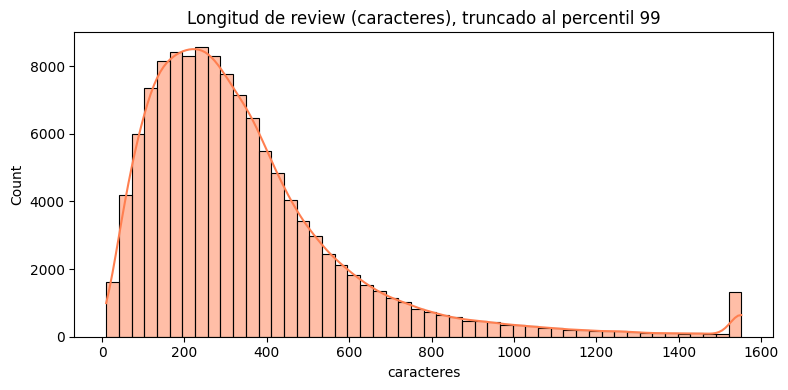

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

In [7]:
import re

# Definir patrones de expresiones regulares para inspeccionar diferentes tipos de caracteres
patterns = {
    'URLs': r'http[s]?://\S+|www\.\S+',
    'Menciones (@)': r'@\w+',
    'Hashtags (#)': r'#\w+',
    'Saltos de línea': r'\n|\r',
    'Números': r'\d+',
    # Un patrón general para capturar signos de puntuación y caracteres especiales
    'Puntuación/Especiales': r'[^\w\s]' 
}

# Iterar sobre los patrones y calcular el porcentaje de reseñas que los contienen
for name, pattern in patterns.items():
    # Usar str.contains de pandas para encontrar coincidencias (ignorando valores nulos)
    matches = df['review'].str.contains(pattern, regex=True, na=False)
    
    # Calcular el porcentaje
    percentage = (matches.sum() / len(df)) * 100
    
    print(f"{name}: {percentage:.2f}% de las reseñas")

print("-------------------------------------------------------")

# Mostrar una muestra aleatoria de 5 reseñas para inspeccionar visualmente emojis o caracteres raros
print("\nMuestra de 5 reseñas aleatorias para inspección visual:")
for idx, text in enumerate(df['review'].dropna().sample(5, random_state=42)):
    print(f"\nReseña {idx + 1}:\n{text}")

URLs: 0.00% de las reseñas
Menciones (@): 0.10% de las reseñas
Hashtags (#): 0.15% de las reseñas
Saltos de línea: 0.31% de las reseñas
Números: 40.86% de las reseñas
Puntuación/Especiales: 96.64% de las reseñas
-------------------------------------------------------

Muestra de 5 reseñas aleatorias para inspección visual:

Reseña 1:
Your wool is great value, the only thing I can comment on is that the wool was not bagged inside for protection.

Reseña 2:
I booked this intensive course in July last year… didn’t start my lessons until November because my first instructor was 2 hours late and didn’t pick up the phone and by the time I had got through to national intensive it was too late for me to have my lesson as I had to go to work. My second instructor then would fall asleep as I was driving and when I was unable to make a lesson and gave him the correct amount of notice, he threatened that if I didn’t pay him he would cancel my driving test which was only 10 days away. I had a back 

## 5) Observamos que tipos de caracteres tenemos y Construimos la funcion de limpieza



In [8]:
def clean_text(text):
    # Convertir el texto a cadena de caracteres y pasarlo a minúsculas
    text = str(text).lower()
    
    # Eliminar URLs y enlaces web
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
    
    # Eliminar menciones de usuarios (@usuario)
    text = re.sub(r'@\w+', '', text)
    
    # Eliminar hashtags (#tema)
    text = re.sub(r'#\w+', '', text)
    
    # Eliminar signos de puntuación y caracteres especiales, sustituyéndolos por un espacio
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Eliminar números
    text = re.sub(r'\d+', ' ', text)
    
    # Eliminar espacios en blanco adicionales, saltos de línea y espacios al principio/final
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Aplicar la función de limpieza para crear una nueva columna con el texto procesado
df['clean_review'] = df['review'].apply(clean_text)

# Mostrar una muestra de las reseñas originales frente a las limpias para verificar los cambios
df[['review', 'clean_review']].head()

,review,clean_review
0,Great quality dog drying robe although had to ...,great quality dog drying robe although had to ...
1,"Really prompt service, The sofa covers have no...",really prompt service the sofa covers have not...
2,I’ve purchased first of those coats in May2020...,i ve purchased first of those coats in may sti...
3,Brilliant coats. Really like the limited editi...,brilliant coats really like the limited editio...
4,Great company and products. This is my 3rd dry...,great company and products this is my rd dryin...


## 6) Filtrado del sector de la compañía objetivo

Filtramos por sector

In [9]:
# Filtramos el dataframe para quedarnos con las reseñas de la categoría de la empresa objetivo
df_sector = df[df['category'] == CAT].copy()

# Creamos una columna de booleanos para marcar si la reseña pertenece a la empresa objetivo
df_sector['is_target'] = df_sector['company'] == TARGET

# Mostramos los resultados tras aplicar el filtro
print(f"Total de reseñas en el sector '{CAT}': {len(df_sector)}")
print(f"Total de reseñas de la empresa objetivo ({TARGET}): {df_sector['is_target'].sum()}")

Total de reseñas en el sector 'Animals & Pets': 5446
Total de reseñas de la empresa objetivo (ruffandtumbledogcoats.com): 59


## 7) Sentimiento
Aplicamos la funcion de limpieza y el sentimiento


In [10]:
# Inicializamos el pipeline de análisis de sentimiento
# Usamos un modelo estándar y rápido en inglés (DistilBERT) ya que las reseñas del dataset están en inglés

sentiment_pipeline = pipeline(
    "sentiment-analysis", 
    model="distilbert-base-uncased-finetuned-sst-2-english", 
    truncation=True, 
    max_length=512
)

# Función para extraer únicamente la etiqueta (POSITIVE/NEGATIVE)
def get_sentiment(text):
    try:
        # Obtenemos la salida del modelo predictivo
        result = sentiment_pipeline(text)[0]
        return result['label']
    except Exception as e:
        # Valor de respaldo en caso de que la fila esté vacía o dé algún error de procesamiento
        return "NEUTRAL"

# Aplicamos el modelo de sentimiento a nuestra columna de texto limpio en el dataframe del sector
df_sector['sentiment'] = df_sector['clean_review'].apply(get_sentiment)

# Mostramos una muestra para verificar que la nueva columna se ha generado correctamente
df_sector[['clean_review', 'sentiment']].head()

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1747.42it/s]


,clean_review,sentiment
0,great quality dog drying robe although had to ...,NEGATIVE
1,really prompt service the sofa covers have not...,NEGATIVE
2,i ve purchased first of those coats in may sti...,POSITIVE
3,brilliant coats really like the limited editio...,POSITIVE
4,great company and products this is my rd dryin...,POSITIVE


In [11]:
# Creamos un DataFrame para la empresa objetivo y otro para la competencia
target_company = TARGET
empresa_df = df_sector[df_sector["company"] == target_company]
competencia_df = df_sector[df_sector["company"] != target_company]

# Calculamos los conteos normalizados de sentimiento para la empresa objetivo
empresa_sent = (
    empresa_df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Calculamos los conteos normalizados de sentimiento para la competencia
competencia_sent = (
    competencia_df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Concatenamos los resultados en un solo DataFrame para facilitar la comparación
comparacion_sentimiento = pd.concat(
    [empresa_sent, competencia_sent],
    axis=1
)

# Renombramos las columnas para mayor claridad
comparacion_sentimiento.columns = [
    "Empresa",
    "Competencia"
]

display(comparacion_sentimiento)

,Empresa,Competencia
sentiment,,
NEGATIVE,57.63,63.89
POSITIVE,42.37,36.11


## 8) Topics



In [12]:
#%pip install --no-deps bertopic
#%pip install --upgrade numpy hdbscan umap-learn pandas scikit-learn tqdm plotly pyyaml
from bertopic import BERTopic

# BERTopic funciona mejor pasando directamente una lista de textos
docs = df_sector['clean_review'].dropna().tolist()

# Inicializamos el modelo BERTopic
# Indicamos el idioma en inglés para que use el Transformer adecuado por debajo
topic_model = BERTopic(language="english", calculate_probabilities=True, verbose=True)

# Entrenamos el modelo y extraemos los temas
# Nota: Esto puede tardar unos minutos dependiendo de los recursos de tu ordenador
topics, probabilities = topic_model.fit_transform(docs)

# Añadimos los temas asignados de vuelta a nuestro dataframe
# Como eliminamos los nulos (dropna) para la lista 'docs', tenemos que asegurarnos de mapearlo correctamente
df_sector.loc[df_sector['clean_review'].notna(), 'topic'] = topics

# Generamos un resumen con los temas encontrados
topic_info = topic_model.get_topic_info()

print("--- Temas descubiertos por BERTopic ---")
# El topic "-1" siempre hace referencia al "ruido" o textos que el modelo no pudo clasificar
print(topic_info.head(10))

2026-06-27 16:16:44,208 - BERTopic - Embedding - Transforming documents to embeddings.
2026-06-27 16:16:44,224 - BERTopic - Automatically selecting lightweight scikit-learn embedding backend as sentence-transformers appears to not be installed.
2026-06-27 16:16:46,373 - BERTopic - Embedding - Completed ✓
2026-06-27 16:16:46,373 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-27 16:17:30,489 - BERTopic - Dimensionality - Completed ✓
2026-06-27 16:17:30,493 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-27 16:17:31,430 - BERTopic - Cluster - Completed ✓
2026-06-27 16:17:31,440 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-27 16:17:31,859 - BERTopic - Representation - Completed ✓


--- Temas descubiertos por BERTopic ---
   Topic  Count                           Name  \
0     -1   2220               -1_the_and_to_it   
1      0    360               0_we_our_us_were   
2      1    282               1_was_vet_to_the   
3      2    189            2_they_vets_are_and   
4      3    166      3_flea_treatment_fleas_my   
5      4    140     4_delivery_day_next_parcel   
6      5    139             5_her_she_and_with   
7      6    138            6_you_your_that_are   
8      7    137  7_fast_easy_products_delivery   
9      8    131              8_food_dog_wet_is   

                                      Representation  \
0     [the, and, to, it, my, is, for, have, of, was]   
1    [we, our, us, were, to, and, the, was, in, had]   
2     [was, vet, to, the, my, and, me, he, had, him]   
3  [they, vets, are, and, to, their, them, have, ...   
4  [flea, treatment, fleas, my, for, month, treat...   
5  [delivery, day, next, parcel, was, the, delive...   
6    [her, she, a

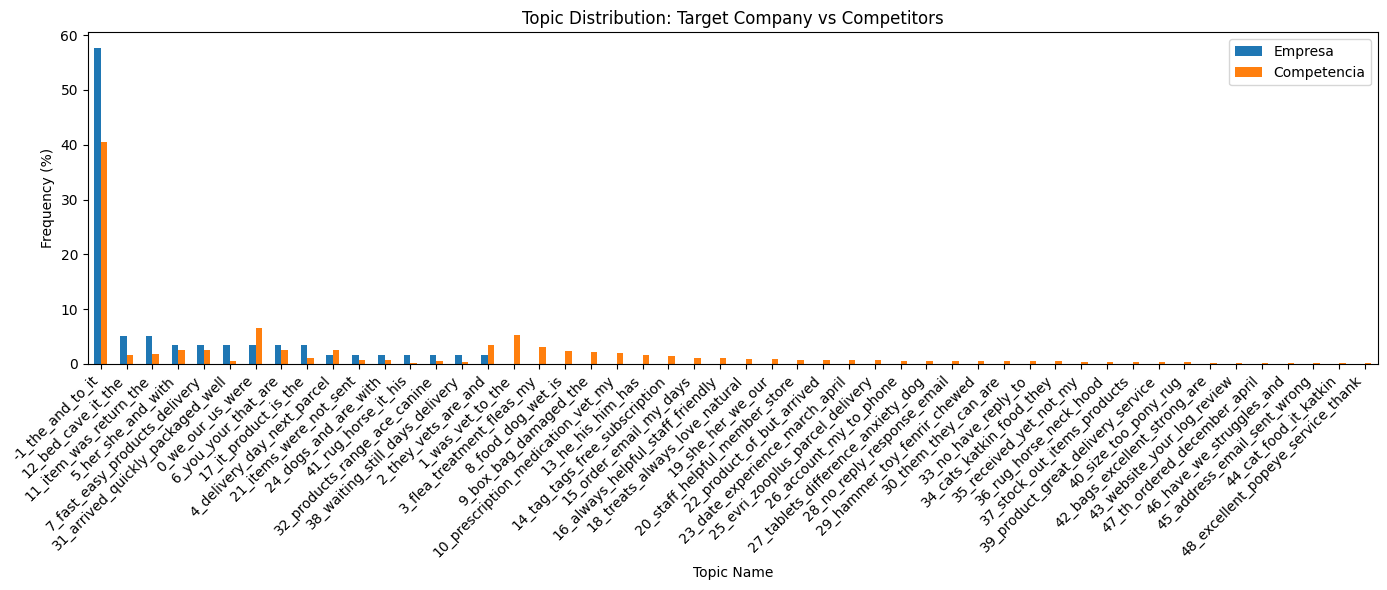

In [13]:
# Volvemos a filtrar el dataframe para quedarnos con las reseñas de la empresa objetivo y de la competencia
target_company = TARGET
empresa_df = df_sector[df_sector["company"] == target_company]
competencia_df = df_sector[df_sector["company"] != target_company]

# Calculamos las proporciones de temas para la empresa objetivo
empresa_topics = empresa_df['topic'].value_counts(normalize=True).mul(100).rename('Empresa')

# Calculamos las proporciones de temas para la competencia
competencia_topics = competencia_df['topic'].value_counts(normalize=True).mul(100).rename('Competencia')

# Concatenamos ambos series y rellenamos los valores faltantes con 0
comparacion_topics = pd.concat([empresa_topics, competencia_topics], axis=1).fillna(0)

# Fusionamos con los nombres de los temas para hacer el gráfico legible
topic_names = topic_info[['Topic', 'Name']].set_index('Topic')
comparacion_topics = comparacion_topics.join(topic_names).set_index('Name')

# Graficamos la distribución de los temas
comparacion_topics.plot(kind='bar', figsize=(14, 6))
plt.title('Topic Distribution: Target Company vs Competitors')
plt.ylabel('Frequency (%)')
plt.xlabel('Topic Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Inicializamos un vectorizador de conteo personalizado para eliminar palabras vacías en inglés como ocurría en el caso anterior
vectorizer_model = CountVectorizer(stop_words="english")

# Inicializamos el modelo BERTopic pasando el vectorizador personalizado
topic_model_clean = BERTopic(vectorizer_model=vectorizer_model, language="english")

# Extraemos los textos del dataframe en una lista (ajusta el nombre de la columna si es necesario)
docs = df_sector["review"].tolist() 

# Ajustamos el modelo y generamos los nuevos temas
topics_clean, probs_clean = topic_model_clean.fit_transform(docs)

# Desplegamos la información de los nuevos temas para observar las diferencias
topic_info_clean = topic_model_clean.get_topic_info()
display(topic_info_clean.head(15))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2275,-1_delivery_order_food_good,"[delivery, order, food, good, dog, service, co...",[I was so hopeful with this food as read the g...
1,0,516,0_vet_vets_dog_told,"[vet, vets, dog, told, pet, money, care, just,...",[My cat had 4 kittens. First check up for all ...
2,1,318,1_vet_dog_pet_home,"[vet, dog, pet, home, airpets, time, process, ...",[We had hoped to write a glowing review of Air...
3,2,179,2_flea_treatment_fleas_month,"[flea, treatment, fleas, month, treatments, wo...",[Cannot recommend their flea treatment at all....
4,3,161,3_dont_review_state_just,"[dont, review, state, just, pay, product, than...","[Good product, delivery times were abysmal but..."
5,4,123,4_shes_coat_dog_food,"[shes, coat, dog, food, old, like, amazing, fa...",[My 10yr old pointer had been on Lily’s kitche...
6,5,114,5_prescription_medication_order_vet,"[prescription, medication, order, vet, animed,...","[Easy ordering service, having uploaded our pr..."
7,6,111,6_bed_cave_beds_quality,"[bed, cave, beds, quality, dog, hood, bought, ...",[The only place I could get a cave bed in this...
8,7,100,7_box_bag_damaged_split,"[box, bag, damaged, split, arrived, contents, ...",[Normally I give Trusty Pets a FIVE STAR revie...
9,8,91,8_food_dog_wet_kibble,"[food, dog, wet, kibble, dry, eat, chicken, do...",[I ordered both dry and wet food for my dogs. ...


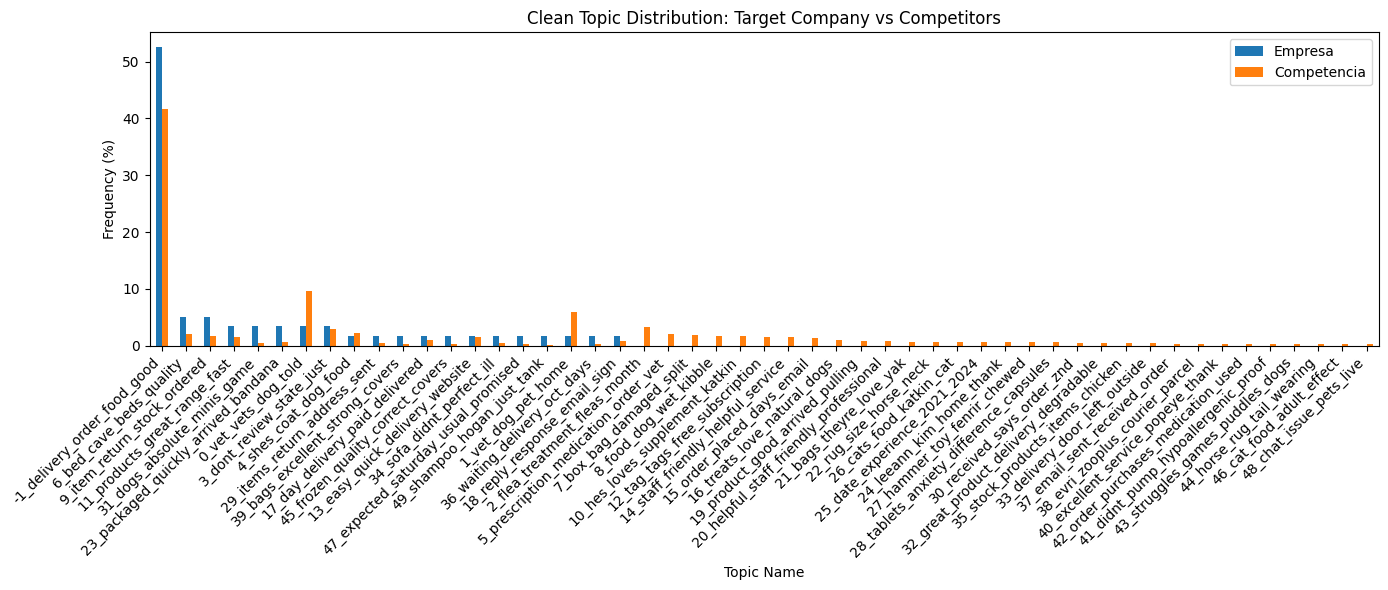

In [19]:
# Asignamos los temas limpios al dataframe original para su posterior análisis
df_sector['topic_clean'] = topics_clean

# Volver a filtrar los dataframes usando la variable de la empresa objetivo
target_company = TARGET 
empresa_df_clean = df_sector[df_sector["company"] == target_company]
competencia_df_clean = df_sector[df_sector["company"] != target_company]

# Calculamos las proporciones de temas para la empresa objetivo
empresa_topics_clean = empresa_df_clean['topic_clean'].value_counts(normalize=True).mul(100).rename('Empresa')

# Calculamos las proporciones de temas para la competencia
competencia_topics_clean = competencia_df_clean['topic_clean'].value_counts(normalize=True).mul(100).rename('Competencia')

# Concatenamos ambos series y rellenamos los valores faltantes con 0
comparacion_topics_clean = pd.concat([empresa_topics_clean, competencia_topics_clean], axis=1).fillna(0)

# Unimos con los nombres de los temas limpios para hacer el gráfico legible
topic_names_clean = topic_info_clean[['Topic', 'Name']].set_index('Topic')
comparacion_topics_clean = comparacion_topics_clean.join(topic_names_clean).set_index('Name')

# Mostramos la comparación de temas limpios entre la empresa objetivo y la competencia
comparacion_topics_clean.plot(kind='bar', figsize=(14, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Clean Topic Distribution: Target Company vs Competitors')
plt.ylabel('Frequency (%)')
plt.xlabel('Topic Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 9) Visualizaciones

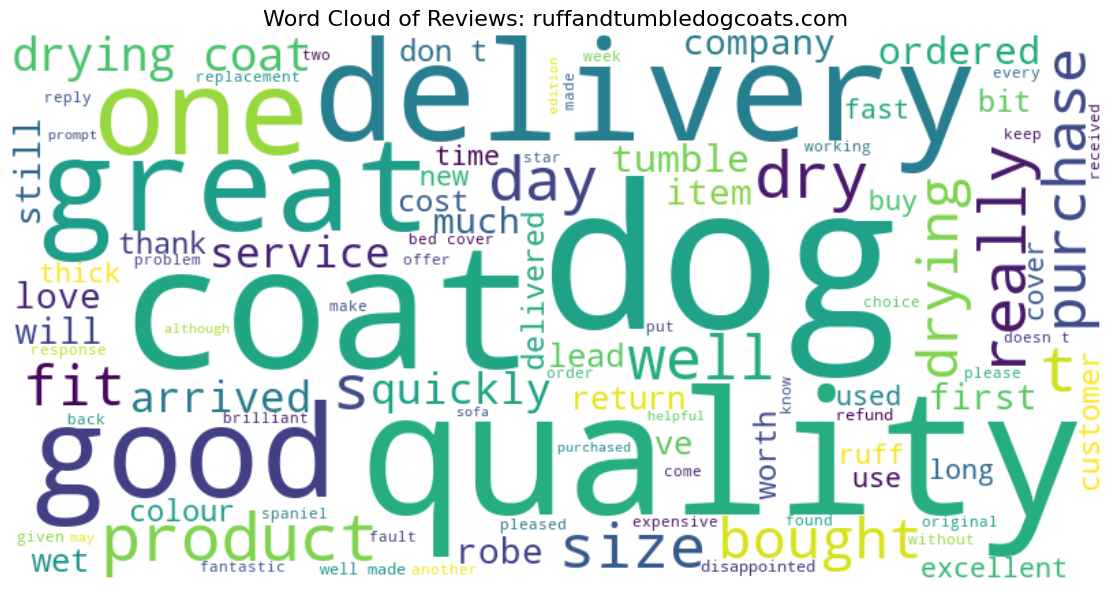

In [14]:
from wordcloud import WordCloud

# Combine all cleaned reviews for the target company into a single text string
target_reviews = " ".join(df_sector[df_sector['is_target'] == True]['clean_review'].dropna())

# Generate the WordCloud object with specific visual parameters
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='viridis', 
    max_words=100
).generate(target_reviews)

# Plot the generated WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f'Word Cloud of Reviews: {TARGET}', fontsize=16)
plt.tight_layout()
plt.show()

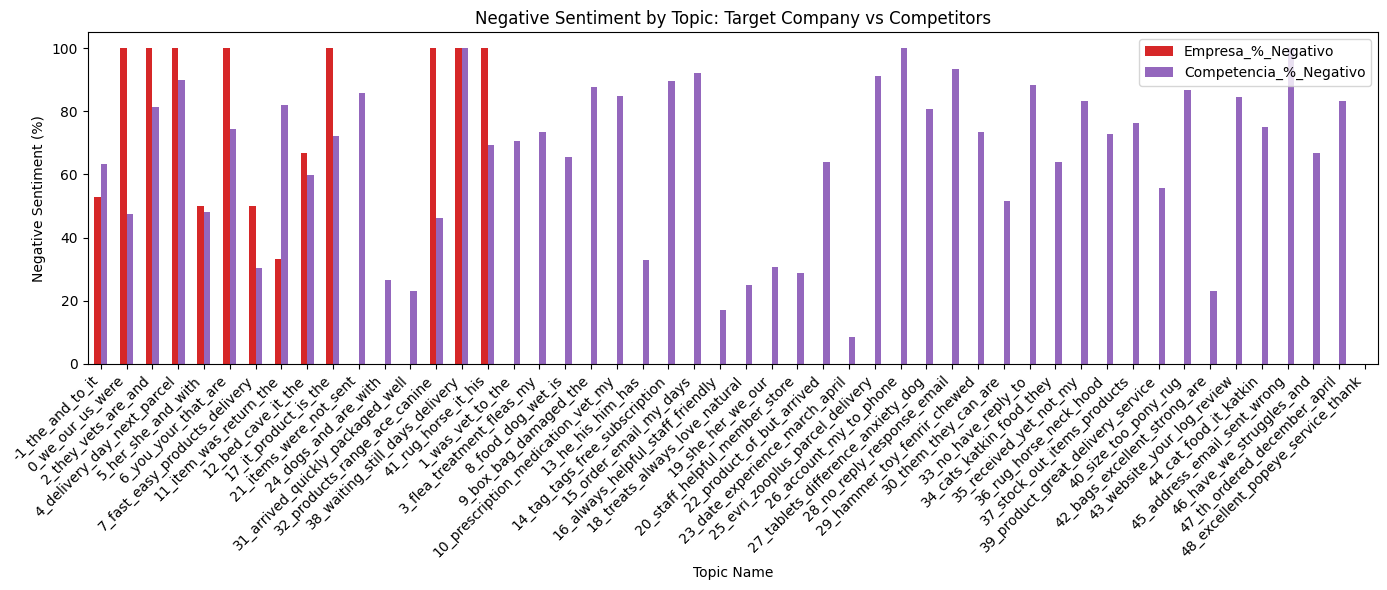

In [15]:
# Agrupamos por tema y sentimiento, calculamos las proporciones y extraemos el porcentaje de NEGATIVO para la empresa objetivo
empresa_topic_sent = empresa_df.groupby('topic')['sentiment'].value_counts(normalize=True).unstack().fillna(0)
empresa_topic_sent_neg = (empresa_topic_sent.get('NEGATIVE', pd.Series(0, index=empresa_topic_sent.index)) * 100).rename('Empresa_%_Negativo')

# Agrupamos por tema y sentimiento, calculamos las proporciones y extraemos el porcentaje de NEGATIVO para la competencia
competencia_topic_sent = competencia_df.groupby('topic')['sentiment'].value_counts(normalize=True).unstack().fillna(0)
competencia_topic_sent_neg = (competencia_topic_sent.get('NEGATIVE', pd.Series(0, index=competencia_topic_sent.index)) * 100).rename('Competencia_%_Negativo')

# Concatenamos ambos series y rellenamos los valores faltantes con 0
comparacion_sent_topic = pd.concat([empresa_topic_sent_neg, competencia_topic_sent_neg], axis=1).fillna(0)

# Fusionamos con los nombres de los temas para hacer el gráfico legible
comparacion_sent_topic = comparacion_sent_topic.join(topic_names).set_index('Name')

# Graficamos la comparación de sentimiento negativo
comparacion_sent_topic.plot(kind='bar', figsize=(14, 6), color=['#d62728', '#9467bd'])
plt.title('Negative Sentiment by Topic: Target Company vs Competitors')
plt.ylabel('Negative Sentiment (%)')
plt.xlabel('Topic Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()